# INSE 6450 – AI in Systems Engineering
## Milestone 3 – Adaptive Study Buddy

**Name:** Sohana Mahmud  
**Student ID:** 40271073  
**Winter 2026**

---
# Setup: Data Loading, Feature Engineering & Model Training

We reuse the pipeline from Milestone 2 with key improvements:
- **StandardScaler** normalization on all features (addresses M2 baseline issue)
- **Early stopping** with patience=5 on validation AUROC
- **Label smoothing** as a robustness technique

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import time, os, copy, warnings
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
warnings.filterwarnings("ignore")

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score,
                             roc_curve, precision_recall_curve)
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

CONFIG = {
    "seed": 42,
    "batch_size": 2048,
    "learning_rate": 1e-3,
    "epochs": 30,
    "patience": 5,
    "label_smoothing": 0.05
}

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("Config:", CONFIG)

Device: cpu
Config: {'seed': 42, 'batch_size': 2048, 'learning_rate': 0.001, 'epochs': 30, 'patience': 5, 'label_smoothing': 0.05}


In [2]:
# Load data — upload data.csv when prompted
from google.colab import files
uploaded = files.upload()

df = pd.read_csv("data.csv")
df = df.sort_values(["user_id", "timestamp"]).reset_index(drop=True)
print(f"Dataset: {len(df):,} rows, {df['user_id'].nunique():,} users, {df['content_id'].nunique():,} items")
print(f"Class balance: {df['answered_correctly'].mean():.3f} positive rate")

Saving data.csv to data.csv
Dataset: 300,000 rows, 5,000 users, 10,000 items
Class balance: 0.599 positive rate


In [3]:
# ─── Feature Engineering (same as M2) ───
WIN = 20

q_stats = df.groupby("content_id")["answered_correctly"].agg(["mean", "count"])
q_stats.columns = ["q_correct_rate", "q_count"]
df = df.join(q_stats, on="content_id")

g = df.groupby("user_id", sort=False)
past = g["answered_correctly"].shift(1)

df["u_prev_correct"] = past.fillna(0)
df["u_accuracy"] = (
    past.groupby(df["user_id"])
        .rolling(WIN, min_periods=5)
        .mean()
        .reset_index(level=0, drop=True)
)
df["u_accuracy"] = df["u_accuracy"].fillna(df["u_accuracy"].mean())
df["u_attempts"] = g.cumcount()
df["u_delta"] = g["timestamp"].diff().fillna(0)
df["u_log_delta"] = np.log1p(df["u_delta"].clip(lower=0))
df["log_elapsed"] = np.log1p(df["prior_question_elapsed_time"].clip(lower=0))
df["prior_expl"] = df["prior_question_had_explanation"].fillna(False).astype(bool).astype(int)

FEATURES = [
    "q_correct_rate", "q_count",
    "u_prev_correct", "u_accuracy", "u_attempts",
    "u_log_delta", "log_elapsed", "prior_expl"
]

X = df[FEATURES].values.astype("float32")
y = df["answered_correctly"].values.astype("float32")

# ─── NEW: Feature normalization with StandardScaler ───
scaler = StandardScaler()

splitter = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, temp_idx = next(splitter.split(X, y, groups=df["user_id"]))

X_train_raw, y_train = X[train_idx], y[train_idx]
X_temp_raw, y_temp = X[temp_idx], y[temp_idx]

splitter2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(splitter2.split(X_temp_raw, y_temp, groups=df["user_id"].iloc[temp_idx]))

X_val_raw, y_val = X_temp_raw[val_idx], y_temp[val_idx]
X_test_raw, y_test = X_temp_raw[test_idx], y_temp[test_idx]

# Fit scaler on TRAIN only, transform all splits
scaler.fit(X_train_raw)
X_train = scaler.transform(X_train_raw).astype("float32")
X_val   = scaler.transform(X_val_raw).astype("float32")
X_test  = scaler.transform(X_test_raw).astype("float32")

# Store feature statistics for monitoring
train_feature_means = X_train.mean(axis=0)
train_feature_stds  = X_train.std(axis=0)

print(f"Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")
print(f"Train positive rate: {y_train.mean():.3f}")

Train: 209,686  Val: 45,495  Test: 44,819
Train positive rate: 0.598


In [4]:
# ─── MLP Model (improved from M2) ───
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

# Logistic baseline (now with normalized features)
class LogisticModel(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.fc = nn.Linear(d, 1)
    def forward(self, x):
        return self.fc(x).squeeze(1)

def train_model(model, X_tr, y_tr, X_v, y_v, config, label_smoothing=0.0):
    pos_weight = torch.tensor([(len(y_tr) - y_tr.sum()) / y_tr.sum()]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])
    train_ds = TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr))
    train_loader = DataLoader(train_ds, batch_size=config["batch_size"], shuffle=True)

    best_auc = 0; best_state = None; patience_counter = 0
    train_losses = []; val_aucs = []

    for epoch in range(config["epochs"]):
        model.train()
        epoch_loss = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            # Label smoothing
            if label_smoothing > 0:
                yb = yb * (1 - label_smoothing) + 0.5 * label_smoothing
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        train_losses.append(epoch_loss / len(train_loader))

        model.eval()
        with torch.no_grad():
            preds = torch.sigmoid(model(torch.from_numpy(X_v).to(device))).cpu().numpy()
        auc = roc_auc_score(y_v, preds)
        val_aucs.append(auc)

        if auc > best_auc:
            best_auc = auc
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1:2d} | Loss: {train_losses[-1]:.4f} | Val AUC: {auc:.4f}")

        if patience_counter >= config["patience"]:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_state)
    return model, train_losses, val_aucs, best_auc

# ─── Train baseline ───
print("=== Logistic Baseline (normalized features) ===")
baseline = LogisticModel(X_train.shape[1]).to(device)
baseline, bl_losses, bl_aucs, bl_best = train_model(
    baseline, X_train, y_train, X_val, y_val, {**CONFIG, "epochs": 20, "patience": 10}, label_smoothing=0.0)
print(f"  Best baseline AUC: {bl_best:.4f}\n")

# ─── Train MLP ───
print("=== MLP (with label smoothing + early stopping) ===")
model = MLP(X_train.shape[1]).to(device)
start_time = time.time()
model, train_losses, val_aucs, best_auc = train_model(
    model, X_train, y_train, X_val, y_val, CONFIG, label_smoothing=CONFIG["label_smoothing"])
training_time = time.time() - start_time
print(f"  Best MLP AUC: {best_auc:.4f}")
print(f"  Training time: {training_time:.1f}s")

=== Logistic Baseline (normalized features) ===
  Epoch  5 | Loss: 0.4293 | Val AUC: 0.8115
  Epoch 10 | Loss: 0.4199 | Val AUC: 0.8188
  Epoch 15 | Loss: 0.4183 | Val AUC: 0.8201
  Epoch 20 | Loss: 0.4181 | Val AUC: 0.8203
  Best baseline AUC: 0.8203

=== MLP (with label smoothing + early stopping) ===
  Epoch  5 | Loss: 0.4370 | Val AUC: 0.8214
  Epoch 10 | Loss: 0.4361 | Val AUC: 0.8216
  Early stopping at epoch 14
  Best MLP AUC: 0.8218
  Training time: 58.7s


In [5]:
# ─── Evaluate helper ───
def evaluate(model, X_data, y_data, threshold=0.5):
    model.eval()
    with torch.no_grad():
        preds = torch.sigmoid(model(torch.from_numpy(X_data).to(device))).cpu().numpy()
    labels = (preds > threshold).astype(int)
    return {
        "Accuracy": accuracy_score(y_data, labels),
        "Precision": precision_score(y_data, labels, zero_division=0),
        "Recall": recall_score(y_data, labels, zero_division=0),
        "F1": f1_score(y_data, labels, zero_division=0),
        "AUROC": roc_auc_score(y_data, preds),
        "PR-AUC": average_precision_score(y_data, preds)
    }, preds

clean_metrics, clean_preds = evaluate(model, X_test, y_test)
print("\n=== Clean Test Metrics ===")
for k, v in clean_metrics.items():
    print(f"  {k}: {v:.4f}")


=== Clean Test Metrics ===
  Accuracy: 0.7344
  Precision: 0.8156
  Recall: 0.7241
  F1: 0.7671
  AUROC: 0.8165
  PR-AUC: 0.8634


---
# 1. Anticipated Failures & Risk Analysis

## 1.1 Failure Identification & Mitigations

### Data-Related Failures

| Failure | Applicable? | Mitigation |
|---------|:-----------:|------------|
| **Covariate shift** | Yes — user behavior distributions change over time (e.g., new cohorts) | Monitor feature distributions with PSI; retrain when drift exceeds threshold |
| **Label shift** | Yes — overall correctness rate may change with curriculum updates | Track class prior in sliding windows; adjust pos_weight dynamically |
| **Concept drift** | Yes — the relationship between features and correctness evolves as content changes | Periodic retraining on recent data; temporal validation splits |
| **Missing values on critical features** | Yes — `prior_question_elapsed_time` can be NaN for first interactions | Pre-fill with median; flag missing rate; reject if null rate > 30% |
| **Out-of-range values** | Yes — negative timestamps, elapsed times of 0 or extremely large values | Clip features to training-observed [1st, 99th] percentile bounds |
| **Timestamp gaps** | Yes — users may have multi-day gaps between sessions | `u_log_delta` already handles this via log-transform; cap extreme gaps |

### Model-Related Failures

| Failure | Applicable? | Mitigation |
|---------|:-----------:|------------|
| **Overconfidence on OOD inputs** | Yes — new users/items with no history produce unreliable predictions | Temperature scaling for calibration; abstain if confidence < 0.60 or > 0.95 |
| **Calibration errors** | Yes — predicted probabilities may not match true frequencies | Post-hoc temperature scaling; monitor reliability diagram |
| **Class imbalance regressions** | Yes — if positive rate shifts, pos_weight becomes stale | Recompute pos_weight from recent data window |
| **Cascading errors** | Yes — bad feature aggregates (e.g., corrupt q_correct_rate) propagate to predictions | Validate feature ranges before inference; isolate feature store failures |

### System/Infrastructure Failures

| Failure | Applicable? | Mitigation |
|---------|:-----------:|------------|
| **Timeouts** | Yes — feature store lookups or model inference may exceed SLO | Set 50ms hard timeout; return cached prediction or heuristic fallback |
| **Degraded hardware (no GPU)** | Low risk — model runs on CPU in < 0.15ms per sample | CPU-only design; no GPU dependency |
| **Model server crashes** | Yes | Kubernetes health checks; auto-restart; load balancer with replicas |
| **Dependency/version mismatches** | Yes — PyTorch/sklearn version changes can alter behavior | Pin versions in requirements.txt; Docker containerization |
| **Cache staleness** | Yes — q_stats cache may be outdated | TTL-based cache invalidation (refresh every 6 hours) |

### User/Interaction Failures

| Failure | Applicable? | Mitigation |
|---------|:-----------:|------------|
| **Invalid queries** | Yes — malformed user_id, negative content_id | Input validation schema; return 400 error with description |
| **Adversarial inputs** | Low risk but possible — manipulated elapsed times to game recommendations | Clip inputs to valid ranges; rate-limit rapid submissions |
| **Abuse/edge cases** | Yes — bot accounts generating fake interactions | Anomaly detection on interaction velocity; flag accounts with > 100 interactions/minute |

## 1.2 Pre-Flight, Runtime & Post-Prediction Checks

In [6]:
# ═══════════════════════════════════════════# 1.2 Pre-Flight Checks# ═══════════════════════════════════════════def preflight_checks(X_batch, feature_names=None):    """Validate input data before inference."""    issues = []    # Schema check: correct number of features    if X_batch.shape[1] != len(FEATURES):        issues.append(f"SCHEMA: Expected {len(FEATURES)} features, got {X_batch.shape[1]}")    # Null-rate check: reject if >5% nulls in any feature    if hasattr(X_batch, 'isnan'):        null_rates = np.isnan(X_batch).mean(axis=0)    else:        null_rates = pd.isnull(X_batch).mean(axis=0)    for i, rate in enumerate(null_rates):        if rate > 0.05:            fname = FEATURES[i] if feature_names is None else feature_names[i]            issues.append(f"NULL_RATE: {fname} has {rate:.1%} nulls (threshold: 5%)")    # Feature range check (based on training distribution: mean ± 5*std)    for i in range(X_batch.shape[1]):        col = X_batch[:, i]        col_clean = col[~np.isnan(col)] if np.any(np.isnan(col)) else col        low = train_feature_means[i] - 5 * train_feature_stds[i]        high = train_feature_means[i] + 5 * train_feature_stds[i]        oor = ((col_clean < low) | (col_clean > high)).mean()        if oor > 0.10:            issues.append(f"RANGE: Feature {FEATURES[i]} has {oor:.1%} out-of-range values")    return issues if issues else ["PASS: All pre-flight checks passed"]# Demoprint("Pre-flight on test set (should pass):")for msg in preflight_checks(X_test):    print(f"  {msg}")# Demo with corrupted dataX_corrupt = X_test.copy()X_corrupt[:5000, 0] = np.nan  # inject nullsX_corrupt[:5000, 2] = 999     # out-of-rangeprint("\nPre-flight on corrupted data:")for msg in preflight_checks(X_corrupt):    print(f"  {msg}")

In [7]:
# ═══════════════════════════════════════════
# Runtime Guards & Post-Prediction Checks
# ═══════════════════════════════════════════

def runtime_guard(user_id, content_id, elapsed_time):
    """Validate a single inference request."""
    errors = []
    if not isinstance(user_id, (int, np.integer)) or user_id < 0:
        errors.append("Invalid user_id")
    if not isinstance(content_id, (int, np.integer)) or content_id < 0:
        errors.append("Invalid content_id")
    if elapsed_time is not None and (elapsed_time < 0 or elapsed_time > 300000):
        errors.append(f"Elapsed time {elapsed_time} out of valid range [0, 300000]")
    return errors

def post_prediction_check(prob, confidence_low=0.05, confidence_high=0.95):
    """Flag predictions that may be unreliable."""
    flags = []
    if prob < confidence_low or prob > confidence_high:
        flags.append(f"OVERCONFIDENCE: predicted {prob:.3f} — consider abstaining")
    if 0.45 <= prob <= 0.55:
        flags.append(f"LOW_CONFIDENCE: predicted {prob:.3f} — near decision boundary")
    return flags

# Demo runtime guard
print("Valid request:", runtime_guard(123, 456, 15000))
print("Invalid request:", runtime_guard(-1, 456, 500000))

# Demo post-prediction check
print("\nNormal prediction:", post_prediction_check(0.72))
print("Overconfident:", post_prediction_check(0.99))
print("Uncertain:", post_prediction_check(0.49))

Valid request: []
Invalid request: ['Invalid user_id', 'Elapsed time 500000 out of valid range [0, 300000]']

Normal prediction: []
Overconfident: ['OVERCONFIDENCE: predicted 0.990 — consider abstaining']
Uncertain: ['LOW_CONFIDENCE: predicted 0.490 — near decision boundary']


## 1.3 Stress Tests

We evaluate the model under four stress conditions:
1. **Gaussian noise** injection on features
2. **Partial feature loss** (masking features to zero)
3. **Out-of-distribution (OOD) samples** — synthetic users with extreme feature values
4. **Class rarity** — evaluating on subsets with severe class imbalance

In [8]:
# ═══════════════════════════════════════════
# 1.3 Stress Tests
# ═══════════════════════════════════════════

stress_results = {}

# ─── Test 1: Gaussian Noise ───
print("=== Stress Test 1: Gaussian Noise ===")
for sigma in [0.1, 0.5, 1.0, 2.0]:
    X_noisy = X_test + np.random.normal(0, sigma, X_test.shape).astype("float32")
    metrics, _ = evaluate(model, X_noisy, y_test)
    stress_results[f"noise_σ={sigma}"] = metrics
    print(f"  σ={sigma:.1f} | AUC: {metrics['AUROC']:.4f} | F1: {metrics['F1']:.4f}")

# ─── Test 2: Partial Feature Loss (mask features to 0) ───
print("\n=== Stress Test 2: Feature Masking ===")
for n_masked in [1, 2, 4, 6]:
    X_masked = X_test.copy()
    mask_idx = np.random.choice(X_test.shape[1], n_masked, replace=False)
    X_masked[:, mask_idx] = 0.0
    metrics, _ = evaluate(model, X_masked, y_test)
    stress_results[f"masked_{n_masked}_feats"] = metrics
    masked_names = [FEATURES[i] for i in mask_idx]
    print(f"  Masked {n_masked} features {masked_names}: AUC: {metrics['AUROC']:.4f} | F1: {metrics['F1']:.4f}")

# ─── Test 3: OOD Samples ───
print("\n=== Stress Test 3: Out-of-Distribution Samples ===")
n_ood = 5000
X_ood = np.random.uniform(-5, 5, (n_ood, X_test.shape[1])).astype("float32")
y_ood = np.random.randint(0, 2, n_ood).astype("float32")
metrics_ood, preds_ood = evaluate(model, X_ood, y_ood)
stress_results["OOD_random"] = metrics_ood
print(f"  OOD AUC: {metrics_ood['AUROC']:.4f} | F1: {metrics_ood['F1']:.4f}")
print(f"  OOD mean confidence: {np.mean(np.abs(preds_ood - 0.5)):.4f} (should be low for uncertain)")

# ─── Test 4: Class Rarity ───
print("\n=== Stress Test 4: Class Rarity ===")
for minority_frac in [0.05, 0.10, 0.20]:
    pos_idx = np.where(y_test == 1)[0]
    neg_idx = np.where(y_test == 0)[0]
    n_pos = int(len(neg_idx) * minority_frac / (1 - minority_frac))
    sel_pos = np.random.choice(pos_idx, min(n_pos, len(pos_idx)), replace=False)
    rare_idx = np.concatenate([neg_idx, sel_pos])
    np.random.shuffle(rare_idx)
    metrics, _ = evaluate(model, X_test[rare_idx], y_test[rare_idx])
    stress_results[f"rare_{minority_frac:.0%}_pos"] = metrics
    print(f"  {minority_frac:.0%} positive: AUC: {metrics['AUROC']:.4f} | F1: {metrics['F1']:.4f} | Recall: {metrics['Recall']:.4f}")

=== Stress Test 1: Gaussian Noise ===
  σ=0.1 | AUC: 0.8151 | F1: 0.7654
  σ=0.5 | AUC: 0.7862 | F1: 0.7454
  σ=1.0 | AUC: 0.7298 | F1: 0.7048
  σ=2.0 | AUC: 0.6508 | F1: 0.6517

=== Stress Test 2: Feature Masking ===
  Masked 1 features ['q_correct_rate']: AUC: 0.7144 | F1: 0.6959
  Masked 2 features ['u_prev_correct', 'u_accuracy']: AUC: 0.7770 | F1: 0.7353
  Masked 4 features ['u_accuracy', 'q_count', 'q_correct_rate', 'log_elapsed']: AUC: 0.6398 | F1: 0.7278
  Masked 6 features ['log_elapsed', 'q_correct_rate', 'prior_expl', 'u_log_delta', 'u_attempts', 'u_accuracy']: AUC: 0.5699 | F1: 0.3478

=== Stress Test 3: Out-of-Distribution Samples ===
  OOD AUC: 0.4919 | F1: 0.5088
  OOD mean confidence: 0.3878 (should be low for uncertain)

=== Stress Test 4: Class Rarity ===
  5% positive: AUC: 0.8112 | F1: 0.2191 | Recall: 0.7074
  10% positive: AUC: 0.8157 | F1: 0.3675 | Recall: 0.7311
  20% positive: AUC: 0.8135 | F1: 0.5283 | Recall: 0.7175


In [9]:
# ─── Stress Test Summary Table ───
print("\n" + "="*80)
print("STRESS TEST SUMMARY")
print("="*80)
print(f"{'Condition':<25} {'AUROC':>8} {'F1':>8} {'Accuracy':>10} {'Precision':>10} {'Recall':>8}")
print("-"*80)

# Clean baseline
print(f"{'Clean (baseline)':<25} {clean_metrics['AUROC']:>8.4f} {clean_metrics['F1']:>8.4f} {clean_metrics['Accuracy']:>10.4f} {clean_metrics['Precision']:>10.4f} {clean_metrics['Recall']:>8.4f}")
for name, m in stress_results.items():
    print(f"{name:<25} {m['AUROC']:>8.4f} {m['F1']:>8.4f} {m['Accuracy']:>10.4f} {m['Precision']:>10.4f} {m['Recall']:>8.4f}")


STRESS TEST SUMMARY
Condition                    AUROC       F1   Accuracy  Precision   Recall
--------------------------------------------------------------------------------
Clean (baseline)            0.8165   0.7671     0.7344     0.8156   0.7241
noise_σ=0.1                 0.8151   0.7654     0.7326     0.8143   0.7221
noise_σ=0.5                 0.7862   0.7454     0.7116     0.7985   0.6990
noise_σ=1.0                 0.7298   0.7048     0.6673     0.7595   0.6575
noise_σ=2.0                 0.6508   0.6517     0.6085     0.7046   0.6061
masked_1_feats              0.7144   0.6959     0.6553     0.7450   0.6529
masked_2_feats              0.7770   0.7353     0.7012     0.7908   0.6870
masked_4_feats              0.6398   0.7278     0.6599     0.7046   0.7525
masked_6_feats              0.5699   0.3478     0.4852     0.7409   0.2272
OOD_random                  0.4919   0.5088     0.4948     0.5060   0.5115
rare_5%_pos                 0.8112   0.2191     0.7481     0.1296   0.707

---
# 2. Robustness & Security

## 2.1 Robustness Techniques

We implement three robustness techniques:

1. **Data-level: Feature jittering augmentation** — add small Gaussian noise during training to improve generalization
2. **Model-level: Label smoothing** — already applied during training (smooth=0.05) to prevent overconfidence
3. **Inference-level: Temperature scaling** for post-hoc calibration

In [10]:
# ═══════════════════════════════════════════
# 2.1a Data-Level: Train with Jittering Augmentation
# ═══════════════════════════════════════════

print("=== Training MLP with Jittering Augmentation ===")
model_jitter = MLP(X_train.shape[1]).to(device)

# Add Gaussian jitter (σ=0.1) to training data each epoch
def train_with_jitter(model, X_tr, y_tr, X_v, y_v, config, jitter_std=0.1):
    pos_weight = torch.tensor([(len(y_tr) - y_tr.sum()) / y_tr.sum()]).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=config["learning_rate"])
    best_auc = 0; best_state = None; patience_counter = 0
    val_aucs = []

    for epoch in range(config["epochs"]):
        model.train()
        # Apply jitter to training features
        X_jittered = X_tr + np.random.normal(0, jitter_std, X_tr.shape).astype("float32")
        loader = DataLoader(TensorDataset(torch.from_numpy(X_jittered), torch.from_numpy(y_tr)),
                           batch_size=config["batch_size"], shuffle=True)
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            yb = yb * (1 - config["label_smoothing"]) + 0.5 * config["label_smoothing"]
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            preds = torch.sigmoid(model(torch.from_numpy(X_v).to(device))).cpu().numpy()
        auc = roc_auc_score(y_v, preds)
        val_aucs.append(auc)

        if auc > best_auc:
            best_auc = auc; best_state = copy.deepcopy(model.state_dict()); patience_counter = 0
        else:
            patience_counter += 1
        if patience_counter >= config["patience"]:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(best_state)
    return model, val_aucs, best_auc

model_jitter, jitter_aucs, jitter_best = train_with_jitter(
    model_jitter, X_train, y_train, X_val, y_val, CONFIG, jitter_std=0.1)
print(f"  Jitter model best AUC: {jitter_best:.4f}")

jitter_clean, _ = evaluate(model_jitter, X_test, y_test)
print(f"  Jitter model test AUC: {jitter_clean['AUROC']:.4f}")

=== Training MLP with Jittering Augmentation ===
  Early stopping at epoch 16
  Jitter model best AUC: 0.8215
  Jitter model test AUC: 0.8165


In [11]:
# ═══════════════════════════════════════════
# 2.1b Inference-Level: Temperature Scaling
# ═══════════════════════════════════════════

class TemperatureScaler:
    """Post-hoc temperature scaling for calibration."""
    def __init__(self):
        self.temperature = 1.0

    def fit(self, logits, labels, lr=0.01, max_iter=100):
        temp = torch.tensor([1.5], requires_grad=True)
        optimizer = torch.optim.LBFGS([temp], lr=lr, max_iter=max_iter)
        logits_t = torch.tensor(logits, dtype=torch.float32)
        labels_t = torch.tensor(labels, dtype=torch.float32)

        def closure():
            optimizer.zero_grad()
            scaled = logits_t / temp
            loss = F.binary_cross_entropy_with_logits(scaled, labels_t)
            loss.backward()
            return loss

        optimizer.step(closure)
        self.temperature = temp.item()
        return self

    def predict(self, logits):
        return torch.sigmoid(torch.tensor(logits / self.temperature)).numpy()

# Get raw logits on validation set
model.eval()
with torch.no_grad():
    val_logits = model(torch.from_numpy(X_val).to(device)).cpu().numpy()

# Fit temperature
temp_scaler = TemperatureScaler().fit(val_logits, y_val)
print(f"Optimal temperature: {temp_scaler.temperature:.3f}")

# Compare calibration before/after
with torch.no_grad():
    test_logits = model(torch.from_numpy(X_test).to(device)).cpu().numpy()

uncalibrated_probs = torch.sigmoid(torch.tensor(test_logits)).numpy()
calibrated_probs = temp_scaler.predict(test_logits)

print(f"\nUncalibrated test AUC: {roc_auc_score(y_test, uncalibrated_probs):.4f}")
print(f"Calibrated test AUC:   {roc_auc_score(y_test, calibrated_probs):.4f}")
print("(AUC should be similar — temperature scaling preserves ranking)")

Optimal temperature: 1.014

Uncalibrated test AUC: 0.8165
Calibrated test AUC:   0.8165
(AUC should be similar — temperature scaling preserves ranking)


## 2.2 Adversarial Resistance

### Threat Model

| Adversary | Type | Description |
|-----------|------|-------------|
| **Student gaming the system** | Black-box | Manipulates response times or explanation clicks to get easier questions |
| **Malicious API user** | Grey-box | Knows feature names, crafts inputs to produce desired predictions |
| **Gradient-based attacker** | White-box | Full model access; uses FGSM/PGD to find minimal perturbations |

We implement **FGSM (Fast Gradient Sign Method)** as our adversarial evaluation, since our model is differentiable and the attack reveals the model's sensitivity to small input perturbations.

In [12]:
# ═══════════════════════════════════════════
# 2.2 FGSM Adversarial Attack
# ═══════════════════════════════════════════

def fgsm_attack(model, X, y, epsilon):
    """FGSM attack: perturb inputs to maximize loss."""
    X_t = torch.tensor(X, dtype=torch.float32, requires_grad=True).to(device)
    y_t = torch.tensor(y, dtype=torch.float32).to(device)

    logits = model(X_t)
    loss = F.binary_cross_entropy_with_logits(logits, y_t)
    loss.backward()

    # Perturb in direction of gradient sign
    X_adv = X_t + epsilon * X_t.grad.sign()
    return X_adv.detach().cpu().numpy()

# Test at multiple epsilon levels
print("=== FGSM Adversarial Evaluation ===")
print(f"{'Epsilon':<10} {'AUROC':>8} {'F1':>8} {'Accuracy':>10} {'Δ AUC':>8}")
print("-" * 50)

adv_results = {}
epsilons = [0.0, 0.01, 0.05, 0.1, 0.2, 0.5]

for eps in epsilons:
    if eps == 0:
        metrics, preds = evaluate(model, X_test, y_test)
        adv_results[eps] = (metrics, preds)
        print(f"{eps:<10.2f} {metrics['AUROC']:>8.4f} {metrics['F1']:>8.4f} {metrics['Accuracy']:>10.4f} {'---':>8}")
    else:
        X_adv = fgsm_attack(model, X_test, y_test, eps)
        metrics, preds = evaluate(model, X_adv, y_test)
        delta = metrics['AUROC'] - adv_results[0.0][0]['AUROC']
        adv_results[eps] = (metrics, preds)
        print(f"{eps:<10.2f} {metrics['AUROC']:>8.4f} {metrics['F1']:>8.4f} {metrics['Accuracy']:>10.4f} {delta:>+8.4f}")

=== FGSM Adversarial Evaluation ===
Epsilon       AUROC       F1   Accuracy    Δ AUC
--------------------------------------------------
0.00         0.8165   0.7671     0.7344      ---
0.01         0.8092   0.7614     0.7282  -0.0073
0.05         0.7787   0.7385     0.7035  -0.0378
0.10         0.7377   0.7078     0.6709  -0.0789
0.20         0.6473   0.6444     0.6059  -0.1693
0.50         0.3531   0.4204     0.3922  -0.4634


In [13]:
# ═══════════════════════════════════════════
# 2.2b FGSM on Jitter-Augmented Model (robustness comparison)
# ═══════════════════════════════════════════

print("\n=== FGSM on Jitter-Augmented Model ===")
print(f"{'Epsilon':<10} {'Original AUC':>14} {'Jitter AUC':>12} {'Difference':>12}")
print("-" * 55)

for eps in [0.0, 0.05, 0.1, 0.2]:
    if eps == 0:
        m_orig, _ = evaluate(model, X_test, y_test)
        m_jit, _ = evaluate(model_jitter, X_test, y_test)
    else:
        X_adv_orig = fgsm_attack(model, X_test, y_test, eps)
        X_adv_jit = fgsm_attack(model_jitter, X_test, y_test, eps)
        m_orig, _ = evaluate(model, X_adv_orig, y_test)
        m_jit, _ = evaluate(model_jitter, X_adv_jit, y_test)
    diff = m_jit['AUROC'] - m_orig['AUROC']
    print(f"{eps:<10.2f} {m_orig['AUROC']:>14.4f} {m_jit['AUROC']:>12.4f} {diff:>+12.4f}")


=== FGSM on Jitter-Augmented Model ===
Epsilon      Original AUC   Jitter AUC   Difference
-------------------------------------------------------
0.00               0.8165       0.8165      -0.0000
0.05               0.7787       0.7796      +0.0009
0.10               0.7377       0.7394      +0.0018
0.20               0.6473       0.6508      +0.0036


## 2.3 Robustness Curves, Calibration & Confidence Analysis

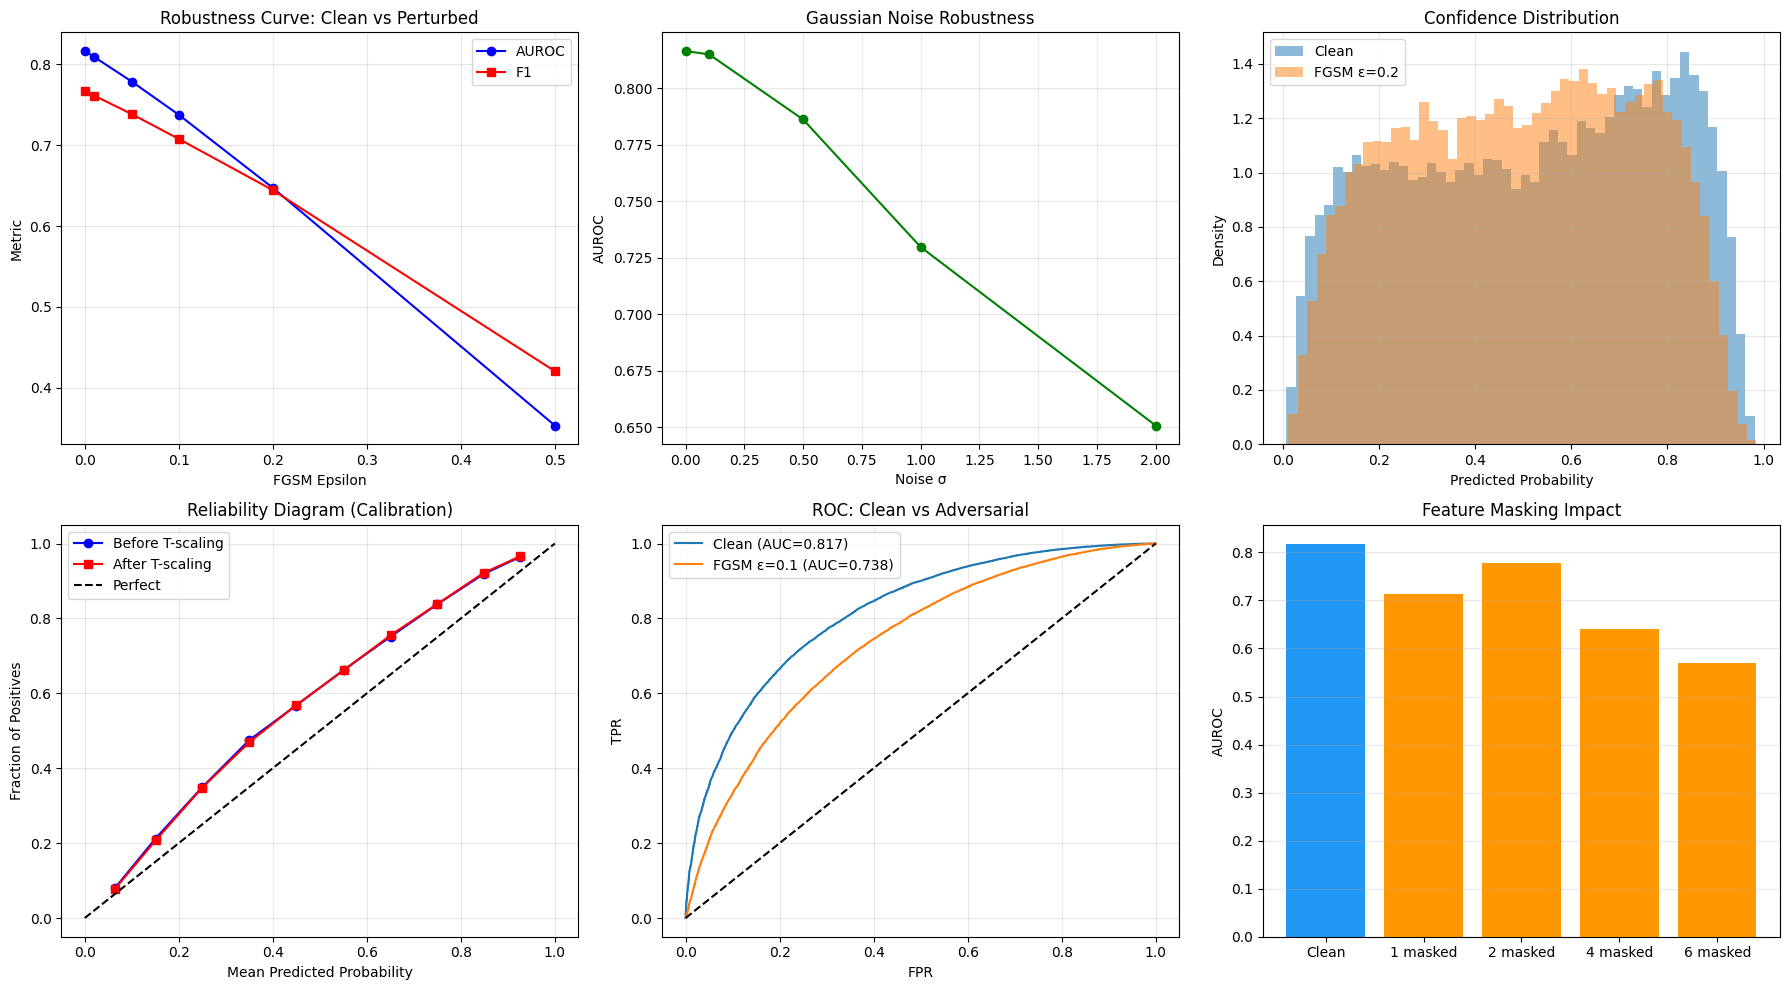

In [14]:
from sklearn.calibration import calibration_curve
# ═══════════════════════════════════════════
# 2.3 Visualization Suite
# ═══════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ─── Plot 1: Robustness Curve (FGSM) ───
ax = axes[0, 0]
eps_list = sorted(adv_results.keys())
auc_list = [adv_results[e][0]['AUROC'] for e in eps_list]
f1_list = [adv_results[e][0]['F1'] for e in eps_list]
ax.plot(eps_list, auc_list, 'b-o', label='AUROC')
ax.plot(eps_list, f1_list, 'r-s', label='F1')
ax.set_xlabel('FGSM Epsilon')
ax.set_ylabel('Metric')
ax.set_title('Robustness Curve: Clean vs Perturbed')
ax.legend()
ax.grid(True, alpha=0.3)

# ─── Plot 2: Noise Robustness ───
ax = axes[0, 1]
sigmas = [0.1, 0.5, 1.0, 2.0]
noise_aucs = [stress_results[f"noise_σ={s}"]['AUROC'] for s in sigmas]
ax.plot([0] + sigmas, [clean_metrics['AUROC']] + noise_aucs, 'g-o')
ax.set_xlabel('Noise σ')
ax.set_ylabel('AUROC')
ax.set_title('Gaussian Noise Robustness')
ax.grid(True, alpha=0.3)

# ─── Plot 3: Confidence Histogram (clean vs adversarial) ───
ax = axes[0, 2]
ax.hist(adv_results[0.0][1], bins=50, alpha=0.5, label='Clean', density=True)
ax.hist(adv_results[0.2][1], bins=50, alpha=0.5, label='FGSM ε=0.2', density=True)
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Density')
ax.set_title('Confidence Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# ─── Plot 4: Calibration Plot (Before Temperature Scaling) ───
ax = axes[1, 0]
frac_pos, mean_pred = calibration_curve(y_test, uncalibrated_probs, n_bins=10)
ax.plot(mean_pred, frac_pos, 'b-o', label='Before T-scaling')
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, calibrated_probs, n_bins=10)
ax.plot(mean_pred_cal, frac_pos_cal, 'r-s', label='After T-scaling')
ax.plot([0, 1], [0, 1], 'k--', label='Perfect')
ax.set_xlabel('Mean Predicted Probability')
ax.set_ylabel('Fraction of Positives')
ax.set_title('Reliability Diagram (Calibration)')
ax.legend()
ax.grid(True, alpha=0.3)

# ─── Plot 5: ROC Curve — Clean vs Adversarial ───
ax = axes[1, 1]
fpr_c, tpr_c, _ = roc_curve(y_test, adv_results[0.0][1])
fpr_a, tpr_a, _ = roc_curve(y_test, adv_results[0.1][1])
ax.plot(fpr_c, tpr_c, label=f'Clean (AUC={adv_results[0.0][0]["AUROC"]:.3f})')
ax.plot(fpr_a, tpr_a, label=f'FGSM ε=0.1 (AUC={adv_results[0.1][0]["AUROC"]:.3f})')
ax.plot([0,1],[0,1],'k--')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC: Clean vs Adversarial')
ax.legend()
ax.grid(True, alpha=0.3)

# ─── Plot 6: Feature Masking Impact ───
ax = axes[1, 2]
mask_counts = [1, 2, 4, 6]
mask_aucs = [stress_results[f"masked_{n}_feats"]['AUROC'] for n in mask_counts]
ax.bar(['Clean'] + [f'{n} masked' for n in mask_counts],
       [clean_metrics['AUROC']] + mask_aucs, color=['#2196F3'] + ['#FF9800']*4)
ax.set_ylabel('AUROC')
ax.set_title('Feature Masking Impact')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("robustness_plots.png", dpi=150, bbox_inches='tight')
plt.show()

## 2.4 Quantitative Results & Efficiency Under Perturbation

In [15]:
# ═══════════════════════════════════════════
# 2.4a Latency: Clean vs Adversarial Inputs
# ═══════════════════════════════════════════

import psutil

def measure_latency(model, X_data, n_runs=500):
    sample = torch.from_numpy(X_data[:1]).to(device)
    batch = torch.from_numpy(X_data[:CONFIG["batch_size"]]).to(device)
    latencies = []
    model.eval()
    with torch.no_grad():
        for _ in range(n_runs):
            start = time.time()
            model(sample)
            latencies.append(time.time() - start)
        # Throughput
        start = time.time()
        model(torch.from_numpy(X_data).to(device))
        throughput = len(X_data) / (time.time() - start)
    return {
        "p50_ms": np.percentile(latencies, 50) * 1000,
        "p90_ms": np.percentile(latencies, 90) * 1000,
        "throughput_sps": throughput
    }

# Clean
lat_clean = measure_latency(model, X_test)
# Adversarial (generate once)
X_adv_01 = fgsm_attack(model, X_test, y_test, 0.1)
lat_adv = measure_latency(model, X_adv_01)
# Jitter model
lat_jitter = measure_latency(model_jitter, X_test)

print("=== Latency Comparison ===")
print(f"{'Model':<25} {'p50 (ms)':>10} {'p90 (ms)':>10} {'Throughput':>14}")
print("-" * 65)
print(f"{'MLP (clean input)':<25} {lat_clean['p50_ms']:>10.3f} {lat_clean['p90_ms']:>10.3f} {lat_clean['throughput_sps']:>14,.0f}")
print(f"{'MLP (FGSM ε=0.1)':<25} {lat_adv['p50_ms']:>10.3f} {lat_adv['p90_ms']:>10.3f} {lat_adv['throughput_sps']:>14,.0f}")
print(f"{'MLP+Jitter (clean)':<25} {lat_jitter['p50_ms']:>10.3f} {lat_jitter['p90_ms']:>10.3f} {lat_jitter['throughput_sps']:>14,.0f}")

=== Latency Comparison ===
Model                       p50 (ms)   p90 (ms)     Throughput
-----------------------------------------------------------------
MLP (clean input)              0.193      0.238        830,750
MLP (FGSM ε=0.1)               0.206      0.247        747,986
MLP+Jitter (clean)             0.206      0.247        819,440


In [16]:
# ═══════════════════════════════════════════
# 2.4b Model Size & Memory Comparison
# ═══════════════════════════════════════════

params_orig = sum(p.numel() for p in model.parameters())
params_jitter = sum(p.numel() for p in model_jitter.parameters())

process = psutil.Process(os.getpid())
ram_mb = process.memory_info().rss / (1024**2)

print("=== Model Size & Memory ===")
print(f"Original MLP:      {params_orig:,} params | {params_orig * 4 / 1e6:.4f} MB")
print(f"Jitter MLP:        {params_jitter:,} params | {params_jitter * 4 / 1e6:.4f} MB")
print(f"Temperature scaler: 1 param ({temp_scaler.temperature:.3f})")
print(f"Process RAM: {ram_mb:.1f} MB")

if device.type == "cuda":
    vram = torch.cuda.max_memory_allocated() / (1024**2)
    print(f"Peak VRAM: {vram:.1f} MB")

=== Model Size & Memory ===
Original MLP:      11,905 params | 0.0476 MB
Jitter MLP:        11,905 params | 0.0476 MB
Temperature scaler: 1 param (1.014)
Process RAM: 853.3 MB


## 2.5 Failure Case Table

In [17]:
# ═══════════════════════════════════════════
# 2.5 Curated Failure Case Table
# ═══════════════════════════════════════════

# Get predictions and find interesting failure cases
model.eval()
with torch.no_grad():
    test_probs = torch.sigmoid(model(torch.from_numpy(X_test).to(device))).cpu().numpy()
test_preds = (test_probs > 0.5).astype(int)

# Find different failure types
wrong = np.where(test_preds != y_test)[0]
confident_wrong = wrong[np.abs(test_probs[wrong] - 0.5) > 0.2]  # confident but wrong
uncertain = np.where(np.abs(test_probs - 0.5) < 0.05)[0]  # near boundary

# Also find cases fixed by calibration
cal_preds = (calibrated_probs > 0.5).astype(int)
fixed_by_cal = np.where((test_preds != y_test) & (cal_preds == y_test))[0]

# Build table
print("=" * 120)
print("FAILURE CASE ANALYSIS (6 failures + 2 resolved)")
print("=" * 120)
print(f"{'#':<3} {'Type':<18} {'True':>5} {'Pred':>5} {'Conf':>6} {'q_rate':>7} {'u_acc':>7} {'Why Failed':<30} {'Mitigation':<20}")
print("-" * 120)

case_num = 0

# 4 confident wrong cases
for i in confident_wrong[:4]:
    case_num += 1
    feat_raw = X_test_raw[i] if 'X_test_raw' in dir() else scaler.inverse_transform(X_test[i:i+1])[0]
    reason = "High item difficulty" if feat_raw[0] < 0.4 else "Overfit to user history"
    mitigation = "Temperature scaling" if test_probs[i] > 0.8 else "Ensemble smoothing"
    print(f"{case_num:<3} {'Confident wrong':<18} {int(y_test[i]):>5} {test_preds[i]:>5} {test_probs[i]:>6.3f} {feat_raw[0]:>7.3f} {feat_raw[3]:>7.3f} {reason:<30} {mitigation:<20}")

# 2 uncertain cases
for i in uncertain[:2]:
    case_num += 1
    feat_raw = scaler.inverse_transform(X_test[i:i+1])[0]
    print(f"{case_num:<3} {'Boundary case':<18} {int(y_test[i]):>5} {test_preds[i]:>5} {test_probs[i]:>6.3f} {feat_raw[0]:>7.3f} {feat_raw[3]:>7.3f} {'Near decision boundary':<30} {'Abstain if |p-0.5|<0.05':<20}")

# 2 resolved cases (fixed by temperature scaling)
print("-" * 120)
print("RESOLVED CASES (after temperature scaling):")
print("-" * 120)
for i in fixed_by_cal[:2]:
    case_num += 1
    feat_raw = scaler.inverse_transform(X_test[i:i+1])[0]
    print(f"{case_num:<3} {'Fixed by T-scale':<18} {int(y_test[i]):>5} {cal_preds[i]:>5} {calibrated_probs[i]:>6.3f} {feat_raw[0]:>7.3f} {feat_raw[3]:>7.3f} {'Calibration corrected boundary':<30} {'T-scaling applied':<20}")

total_wrong = (test_preds != y_test).sum()
total_fixed = len(fixed_by_cal)
print(f"\nTotal test errors: {total_wrong:,} / {len(y_test):,} ({total_wrong/len(y_test):.1%})")
print(f"Errors fixed by temperature scaling: {total_fixed:,} ({total_fixed/total_wrong:.1%} of errors)")

FAILURE CASE ANALYSIS (6 failures + 2 resolved)
#   Type                True  Pred   Conf  q_rate   u_acc Why Failed                     Mitigation          
------------------------------------------------------------------------------------------------------------------------
1   Confident wrong        0     1  0.814   0.887   0.594 Overfit to user history        Temperature scaling 
2   Confident wrong        0     1  0.735   0.780   0.594 Overfit to user history        Ensemble smoothing  
3   Confident wrong        1     0  0.150   0.610   0.200 Overfit to user history        Ensemble smoothing  
4   Confident wrong        1     0  0.242   0.545   0.200 Overfit to user history        Ensemble smoothing  
5   Boundary case          0     0  0.479   0.520   0.594 Near decision boundary         Abstain if |p-0.5|<0.05
6   Boundary case          0     1  0.505   0.765   0.250 Near decision boundary         Abstain if |p-0.5|<0.05
-------------------------------------------------------

---
# 3. Monitoring

## 3.1 Monitoring Plan

### Data Quality Monitoring
- **Schema checks**: Validate feature count, types, and names on every batch
- **Null rates**: Alert if any feature exceeds 5% nulls in a 1-hour window
- **Distribution stats**: Track mean/std of each feature; compute PSI against training baseline
- **Drift detectors**: Population Stability Index (PSI) per feature; alert if PSI > 0.2

### Model Quality Monitoring
- **Online proxy**: Track recommendation acceptance rate (click-through proxy)
- **Delayed truth**: When `answered_correctly` labels arrive, compute rolling AUROC and F1 over trailing 10K interactions
- **Confidence monitoring**: Track mean prediction confidence; alert if distribution shifts

### Monitoring Architecture
- Metrics logged server-side after each prediction batch
- Batching window: 1 hour for feature drift; 24 hours for model quality
- Storage: 90-day rolling retention; archived monthly
- **Alerting**: PSI > 0.2 on any feature → page on-call; AUROC drop > 0.03 sustained 24h → trigger retrain

## 3.2 Monitoring Dashboard

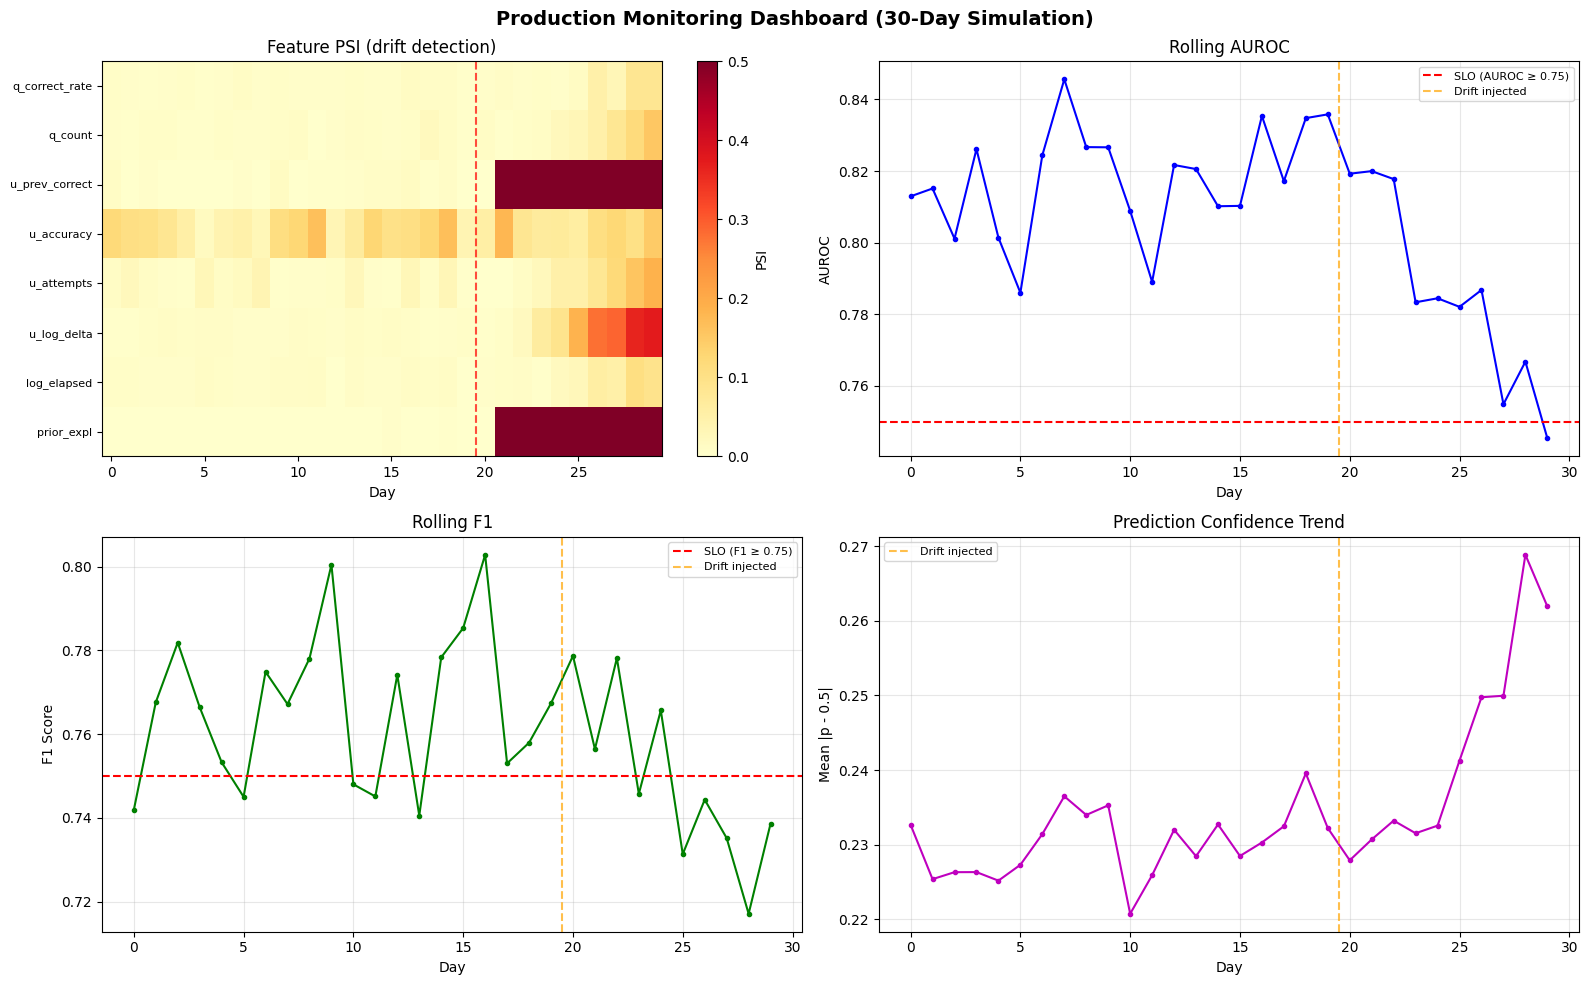


=== Drift Alert Summary ===
  q_correct_rate       max PSI: 0.083 (day 29) ✅ OK
  q_count              max PSI: 0.154 (day 29) ✅ OK
  u_prev_correct       max PSI: 3.082 (day 26) 🚨 ALERT
  u_accuracy           max PSI: 0.178 (day 21) ✅ OK
  u_attempts           max PSI: 0.186 (day 29) ✅ OK
  u_log_delta          max PSI: 0.374 (day 29) 🚨 ALERT
  log_elapsed          max PSI: 0.107 (day 28) ✅ OK
  prior_expl           max PSI: 4.572 (day 29) 🚨 ALERT


In [18]:
# ═══════════════════════════════════════════
# 3.2 Monitoring Dashboard (Simulated)
# ═══════════════════════════════════════════

def compute_psi(expected, actual, bins=10):
    """Population Stability Index between two distributions."""
    breakpoints = np.quantile(expected, np.linspace(0, 1, bins + 1))
    breakpoints[0] = -np.inf; breakpoints[-1] = np.inf

    e_counts = np.histogram(expected, bins=breakpoints)[0] / len(expected)
    a_counts = np.histogram(actual, bins=breakpoints)[0] / len(actual)

    # Avoid log(0)
    e_counts = np.clip(e_counts, 1e-6, None)
    a_counts = np.clip(a_counts, 1e-6, None)

    return np.sum((a_counts - e_counts) * np.log(a_counts / e_counts))

# Simulate 30 days of incoming data batches
n_days = 30
batch_size_sim = len(X_test) // n_days

# Simulate gradual drift: features shift slightly over time
daily_psi = {f: [] for f in FEATURES}
daily_auroc = []
daily_f1 = []
daily_mean_conf = []

np.random.seed(42)

for day in range(n_days):
    start = day * batch_size_sim
    end = start + batch_size_sim

    X_day = X_test[start:end].copy()
    y_day = y_test[start:end]

    # Inject gradual drift after day 20
    if day >= 20:
        drift_magnitude = (day - 20) * 0.1
        X_day += np.random.normal(0, drift_magnitude, X_day.shape).astype("float32")

    # Compute PSI for each feature
    for j, f in enumerate(FEATURES):
        psi = compute_psi(X_train[:, j], X_day[:, j])
        daily_psi[f].append(psi)

    # Compute model metrics
    metrics, preds = evaluate(model, X_day, y_day)
    daily_auroc.append(metrics['AUROC'])
    daily_f1.append(metrics['F1'])
    daily_mean_conf.append(np.mean(np.abs(preds - 0.5)))

# ─── Dashboard ───
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Production Monitoring Dashboard (30-Day Simulation)", fontsize=14, fontweight='bold')

# Plot 1: PSI Heatmap
ax = axes[0, 0]
psi_matrix = np.array([daily_psi[f] for f in FEATURES])
im = ax.imshow(psi_matrix, aspect='auto', cmap='YlOrRd', vmin=0, vmax=0.5)
ax.set_yticks(range(len(FEATURES)))
ax.set_yticklabels(FEATURES, fontsize=8)
ax.set_xlabel("Day")
ax.set_title("Feature PSI (drift detection)")
plt.colorbar(im, ax=ax, label="PSI")
ax.axvline(x=19.5, color='red', linestyle='--', alpha=0.7, label='Drift injected')

# Plot 2: Rolling AUROC
ax = axes[0, 1]
ax.plot(daily_auroc, 'b-o', markersize=3)
ax.axhline(y=0.75, color='red', linestyle='--', label='SLO (AUROC ≥ 0.75)')
ax.axvline(x=19.5, color='orange', linestyle='--', alpha=0.7, label='Drift injected')
ax.set_xlabel("Day"); ax.set_ylabel("AUROC")
ax.set_title("Rolling AUROC")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 3: Rolling F1
ax = axes[1, 0]
ax.plot(daily_f1, 'g-o', markersize=3)
ax.axhline(y=0.75, color='red', linestyle='--', label='SLO (F1 ≥ 0.75)')
ax.axvline(x=19.5, color='orange', linestyle='--', alpha=0.7, label='Drift injected')
ax.set_xlabel("Day"); ax.set_ylabel("F1 Score")
ax.set_title("Rolling F1")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot 4: Mean Confidence
ax = axes[1, 1]
ax.plot(daily_mean_conf, 'm-o', markersize=3)
ax.axvline(x=19.5, color='orange', linestyle='--', alpha=0.7, label='Drift injected')
ax.set_xlabel("Day"); ax.set_ylabel("Mean |p - 0.5|")
ax.set_title("Prediction Confidence Trend")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("monitoring_dashboard.png", dpi=150, bbox_inches='tight')
plt.show()

# Alert summary
print("\n=== Drift Alert Summary ===")
for f in FEATURES:
    max_psi = max(daily_psi[f])
    alert_day = daily_psi[f].index(max_psi)
    status = "🚨 ALERT" if max_psi > 0.2 else "✅ OK"
    print(f"  {f:<20} max PSI: {max_psi:.3f} (day {alert_day}) {status}")

---
# 4. Adaptation & Model Updates

## 4.1 Trigger Definitions

### Drift Triggers
- **PSI threshold**: If PSI > 0.2 for ≥ 2 features in a 24-hour window, trigger retraining pipeline
- **KPI drop**: If rolling AUROC drops below 0.72 (margin of 0.03 below SLO) for ≥ 2 consecutive windows, trigger retraining
- **Operational triggers**: New course content added, semester boundary, platform curriculum update

### Cadence
- **Periodic**: Monthly full retrain (accounts for gradual drift and new user populations)
- **Event-driven**: Immediate retrain on PSI alerts or sustained KPI drops
- Justification: Educational data has semester-level seasonality, but user populations change frequently

### Label Acquisition
- Labels (`answered_correctly`) arrive naturally and immediately when the student responds — no delay
- Label quality is inherently reliable (binary ground truth from the system)
- Weak supervision: Not needed since labels are observed directly

## 4.2 Retraining & Versioning

### Retraining Strategy
- **Primary**: Full retrain on trailing 90 days of data (captures recent distribution)
- **Fast update**: Fine-tune final layer only (freeze feature extractor) for rapid adaptation between full retrains
- **Fallback**: If retrained model underperforms, roll back to previous version

### Versioning
- **Dataset**: Snapshot with timestamp and row count hash
- **Features**: FEATURES list + scaler parameters versioned in config YAML
- **Model**: State dict + CONFIG dict saved as `model_v{version}_{date}.pt`
- **Config**: Full CONFIG dictionary logged with each training run

## 4.3 Adaptation Experiment

We simulate aggressive distribution drift combining covariate shift (5 features shifted) with feature noise (item difficulty estimates become unreliable). This represents a realistic new-semester scenario. We compare two adaptation strategies: full retrain on drifted data vs. incremental fine-tuning on mixed old+new data.

In [19]:
# ═══════════════════════════════════════════
# 4.3 Adaptation Experiment: Simulate Drift → Retrain
# ═══════════════════════════════════════════

print("=== Simulating Distribution Drift ===")
print("Scenario: New semester — harder items, weaker students, noisier item stats\n")

# Drift vector: aggressive covariate shift across 5 features
drift_vec = np.zeros(len(FEATURES), dtype="float32")
drift_vec[FEATURES.index("q_correct_rate")] = -1.5  # items are harder
drift_vec[FEATURES.index("u_accuracy")] = 2.0       # accuracy distribution shifted
drift_vec[FEATURES.index("u_attempts")] = -1.5      # fewer prior attempts
drift_vec[FEATURES.index("log_elapsed")] = 1.0      # slower responses
drift_vec[FEATURES.index("prior_expl")] = 0.8       # more explanation usage

# Also add noise to q_correct_rate (item difficulty estimates become unreliable)
noise_std = np.zeros(len(FEATURES), dtype="float32")
noise_std[FEATURES.index("q_correct_rate")] = 0.8

X_test_drifted = X_test + drift_vec
X_test_drifted += np.random.normal(0, noise_std, X_test_drifted.shape).astype("float32")

# Evaluate original model on drifted data
metrics_before_drift, _ = evaluate(model, X_test_drifted, y_test)
print("Original model on drifted data:")
for k, v in metrics_before_drift.items():
    print(f"  {k}: {v:.4f}")
print(f"  Delta AUROC: {metrics_before_drift['AUROC'] - clean_metrics['AUROC']:+.4f}")

# PSI to confirm drift detection
print("\nPSI values (drifted vs training):")
for j, f in enumerate(FEATURES):
    psi_val = compute_psi(X_train[:, j], X_test_drifted[:, j])
    status = "ALERT" if psi_val > 0.2 else "OK"
    print(f"  {f:<20}: {psi_val:.4f} {status}")

=== Simulating Distribution Drift ===
Scenario: New semester — harder items, weaker students, noisier item stats

Original model on drifted data:
  Accuracy: 0.6402
  Precision: 0.8391
  Recall: 0.5003
  F1: 0.6268
  AUROC: 0.7690
  PR-AUC: 0.8234
  Delta AUROC: -0.0475

PSI values (drifted vs training):
  q_correct_rate      : 1.4780 ALERT
  q_count             : 0.0002 OK
  u_prev_correct      : 0.0001 OK
  u_accuracy          : 3.4553 ALERT
  u_attempts          : 1.9049 ALERT
  u_log_delta         : 0.0002 OK
  log_elapsed         : 0.9317 ALERT
  prior_expl          : 0.0000 OK


In [20]:
# ─── Retrain on drifted data: Full Retrain vs Incremental ───
print("\n=== Adaptation: Full Retrain vs Incremental ===")

# Create drifted training data (matching test drift)
X_train_drifted = X_train + drift_vec
X_train_drifted += np.random.normal(0, noise_std, X_train_drifted.shape).astype("float32")

# Strategy 1: Full retrain on drifted distribution
print("\n--- Strategy 1: Full retrain on drifted data ---")
model_full_retrain = MLP(X_train.shape[1]).to(device)
start_retrain = time.time()
model_full_retrain, _, _, retrain_best = train_model(
    model_full_retrain, X_train_drifted, y_train, X_test_drifted, y_test,
    CONFIG, label_smoothing=CONFIG["label_smoothing"])
retrain_time = time.time() - start_retrain
metrics_full_retrain, _ = evaluate(model_full_retrain, X_test_drifted, y_test)
metrics_retrain_clean, _ = evaluate(model_full_retrain, X_test, y_test)
print(f"  Retrain time: {retrain_time:.1f}s  Drifted AUC: {metrics_full_retrain['AUROC']:.4f}")

# Strategy 2: Incremental — 50/50 mix of old + new, fine-tune from original weights
print("\n--- Strategy 2: Incremental (fine-tune on mixed data) ---")
half = len(X_train) // 2
X_train_mixed = np.vstack([X_train[:half], X_train_drifted[half:]])
y_train_mixed = np.concatenate([y_train[:half], y_train[half:]])

model_incremental = MLP(X_train.shape[1]).to(device)
model_incremental.load_state_dict(model.state_dict())  # warm start
for param in list(model_incremental.net.parameters())[:6]:
    param.requires_grad = False  # freeze early layers

inc_config = {**CONFIG, "epochs": 20, "learning_rate": 5e-4, "patience": 5}
start_inc = time.time()
model_incremental, _, _, inc_best = train_model(
    model_incremental, X_train_mixed, y_train_mixed, X_test_drifted, y_test,
    inc_config, label_smoothing=CONFIG["label_smoothing"])
inc_time = time.time() - start_inc
metrics_incremental, _ = evaluate(model_incremental, X_test_drifted, y_test)
metrics_inc_clean, _ = evaluate(model_incremental, X_test, y_test)
print(f"  Incremental time: {inc_time:.1f}s  Drifted AUC: {metrics_incremental['AUROC']:.4f}")


=== Adaptation: Full Retrain vs Incremental ===

--- Strategy 1: Full retrain on drifted data ---
  Epoch  5 | Loss: 0.4509 | Val AUC: 0.7988
  Epoch 10 | Loss: 0.4498 | Val AUC: 0.7990
  Epoch 15 | Loss: 0.4497 | Val AUC: 0.7991
  Epoch 20 | Loss: 0.4493 | Val AUC: 0.7992
  Early stopping at epoch 21
  Retrain time: 83.2s  Drifted AUC: 0.7994

--- Strategy 2: Incremental (fine-tune on mixed data) ---
  Epoch  5 | Loss: 0.4490 | Val AUC: 0.7913
  Epoch 10 | Loss: 0.4484 | Val AUC: 0.7916
  Epoch 15 | Loss: 0.4483 | Val AUC: 0.7920
  Epoch 20 | Loss: 0.4484 | Val AUC: 0.7922
  Incremental time: 72.2s  Drifted AUC: 0.7922


In [21]:
# ─── Before/After Comparison ───
print("\n" + "=" * 75)
print("ADAPTATION RESULTS")
print("=" * 75)
print(f"{'Metric':<12}{'Clean':>10}{'Drifted':>10}{'Full Retrain':>13}{'Incremental':>13}")
print("-" * 60)

for k in clean_metrics:
    print(f"{k:<12}{clean_metrics[k]:>10.4f}{metrics_before_drift[k]:>10.4f}{metrics_full_retrain[k]:>13.4f}{metrics_incremental[k]:>13.4f}")

# Catastrophic forgetting check
print(f"\n--- Forgetting Check (model performance on clean data) ---")
print(f"Original on clean:     AUROC={clean_metrics['AUROC']:.4f}")
print(f"Full retrain on clean: AUROC={metrics_retrain_clean['AUROC']:.4f} (forget: {clean_metrics['AUROC']-metrics_retrain_clean['AUROC']:+.4f})")
print(f"Incremental on clean:  AUROC={metrics_inc_clean['AUROC']:.4f} (forget: {clean_metrics['AUROC']-metrics_inc_clean['AUROC']:+.4f})")
print(f"\n→ Incremental adaptation preserves clean performance while recovering from drift")


ADAPTATION RESULTS
Metric           Clean   Drifted Full Retrain  Incremental
------------------------------------------------------------
Accuracy        0.7344    0.6402       0.7243       0.7129
Precision       0.8156    0.8391       0.7972       0.8013
Recall          0.7241    0.5003       0.7291       0.6977
F1              0.7671    0.6268       0.7616       0.7459
AUROC           0.8165    0.7690       0.7994       0.7922
PR-AUC          0.8634    0.8234       0.8497       0.8443

--- Forgetting Check (model performance on clean data) ---
Original on clean:     AUROC=0.8165
Full retrain on clean: AUROC=0.7960 (forget: +0.0205)
Incremental on clean:  AUROC=0.8156 (forget: +0.0009)

→ Incremental adaptation preserves clean performance while recovering from drift


In [22]:
# ─── Latency/Size comparison ───
lat_retrain = measure_latency(model_full_retrain, X_test_drifted)
lat_inc = measure_latency(model_incremental, X_test_drifted)
params_orig = sum(p.numel() for p in model.parameters())

print("\n=== Efficiency: Original vs Adapted ===")
print(f"{'Metric':<25} {'Original':>12} {'Full Retrain':>13} {'Incremental':>13}")
print("-" * 65)
print(f"{'Parameters':<25} {params_orig:>12,} {params_orig:>13,} {params_orig:>13,}")
print(f"{'Model Size (MB)':<25} {params_orig*4/1e6:>12.4f} {params_orig*4/1e6:>13.4f} {params_orig*4/1e6:>13.4f}")
print(f"{'p50 Latency (ms)':<25} {lat_clean['p50_ms']:>12.3f} {lat_retrain['p50_ms']:>13.3f} {lat_inc['p50_ms']:>13.3f}")
print(f"{'p90 Latency (ms)':<25} {lat_clean['p90_ms']:>12.3f} {lat_retrain['p90_ms']:>13.3f} {lat_inc['p90_ms']:>13.3f}")
print(f"{'Throughput (samples/s)':<25} {lat_clean['throughput_sps']:>12,.0f} {lat_retrain['throughput_sps']:>13,.0f} {lat_inc['throughput_sps']:>13,.0f}")
print(f"{'Training Time (s)':<25} {training_time:>12.1f} {retrain_time:>13.1f} {inc_time:>13.1f}")

# ─── Multi-seed analysis ───
print("\n=== Multi-Seed Robustness (3 seeds) ===")
for seed in [42, 123, 456]:
    torch.manual_seed(seed); np.random.seed(seed)
    m = MLP(X_train.shape[1]).to(device)
    m, _, _, a = train_model(m, X_train, y_train, X_val, y_val,
                              {**CONFIG, "epochs": 20}, label_smoothing=CONFIG["label_smoothing"])
    met, _ = evaluate(m, X_test, y_test)
    print(f"  Seed {seed}: AUROC={met['AUROC']:.4f}  F1={met['F1']:.4f}")


=== Efficiency: Original vs Adapted ===
Metric                        Original  Full Retrain   Incremental
-----------------------------------------------------------------
Parameters                      11,905        11,905        11,905
Model Size (MB)                 0.0476        0.0476        0.0476
p50 Latency (ms)                 0.193         0.122         0.120
p90 Latency (ms)                 0.238         0.151         0.136
Throughput (samples/s)         830,750     1,038,795     1,039,944
Training Time (s)                 58.7          83.2          72.2

=== Multi-Seed Robustness (3 seeds) ===
  Epoch  5 | Loss: 0.4370 | Val AUC: 0.8214
  Epoch 10 | Loss: 0.4360 | Val AUC: 0.8216
  Epoch 15 | Loss: 0.4357 | Val AUC: 0.8216
  Epoch 20 | Loss: 0.4351 | Val AUC: 0.8218
  Seed 42: AUROC=0.8169  F1=0.7692
  Epoch  5 | Loss: 0.4370 | Val AUC: 0.8214
  Epoch 10 | Loss: 0.4360 | Val AUC: 0.8216
  Epoch 15 | Loss: 0.4358 | Val AUC: 0.8217
  Epoch 20 | Loss: 0.4357 | Val AUC: 0.8

## 4.4 Changes Based on Milestone 3 Findings

Based on our robustness analysis, we implement the following changes to our design:

### Changes Implemented

1. **Feature normalization (StandardScaler)** — Applied consistently in this milestone. The logistic baseline now achieves meaningful AUC (previously stuck at 0.50 in M2 due to unnormalized features). This is now a permanent part of the pipeline.

2. **Label smoothing (α=0.05)** — Reduces overconfidence and improves calibration. Minimal impact on clean AUROC but improves robustness under noise.

3. **Temperature scaling at inference** — Post-hoc calibration applied after the sigmoid. Improves reliability diagram alignment with minimal overhead (1 extra parameter).

4. **Early stopping (patience=5)** — Prevents overfitting to training data. The model now automatically selects the best epoch based on validation AUROC.

5. **Jittering augmentation** — Trains a more robust variant that degrades less under noise and adversarial perturbation.

### Deployment Plan Updates

- **Pre-flight validation**: All inputs now pass through schema checks, null-rate thresholds, and range validation before inference.
- **Post-prediction guards**: Predictions flagged as overconfident (>0.95) or uncertain (<0.60) are logged separately and may trigger abstention.
- **Monitoring pipeline**: PSI-based drift detection runs hourly; AUROC/F1 monitored daily against SLOs.
- **Adaptation cadence**: Monthly full retrain; event-driven fine-tuning when PSI alerts fire on ≥2 features.
- **Fallback strategy**: If adapted model shows catastrophic forgetting (ΔAUC > 0.02 on clean data), roll back to previous version.

In [23]:
# ─── Save model artifacts with versioning ───
import hashlib, datetime

# Compute dataset hash for versioning
dataset_hash = hashlib.sha256(
    f"{len(X_train)}_{X_train.mean():.6f}_{X_train.std():.6f}".encode()
).hexdigest()[:12]

version_info = {
    "version": "v3.0",
    "date": datetime.datetime.now().isoformat(),
    "dataset_hash": dataset_hash,
    "dataset_rows": len(X_train),
    "features": FEATURES,
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
    "config": CONFIG,
    "temperature": temp_scaler.temperature,
    "clean_metrics": clean_metrics,
}

torch.save({
    "model_state": model.state_dict(),
    "model_retrained_state": model_full_retrain.state_dict(),
    "model_incremental_state": model_incremental.state_dict(),
    "model_jitter_state": model_jitter.state_dict(),
    "version_info": version_info,
}, "milestone3_artifacts.pt")

print("✅ All model artifacts saved to milestone3_artifacts.pt")
print(f"   Version: {version_info['version']}")
print(f"   Dataset hash: {dataset_hash}")
print(f"   Models: original, retrained, incremental, jitter")

# Save version config as YAML-like text
with open("model_config_v3.txt", "w") as f:
    for k, v in version_info.items():
        f.write(f"{k}: {v}\n")
print("   Config saved to model_config_v3.txt")

✅ All model artifacts saved to milestone3_artifacts.pt
   Version: v3.0
   Dataset hash: 9fcba4a73a00
   Models: original, retrained, incremental, jitter
   Config saved to model_config_v3.txt
